# Libraries

In [11]:
import os
import shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


from PIL import Image, ImageColor
import torchmetrics

import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch
from torch.utils.data import Dataset, DataLoader
import lightning as L
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp
#from torch.utils.tensorboard import SummaryWriter

# Import tracking and logging tools
import mlflow
import mlflow.pytorch
from lightning.pytorch.loggers import MLFlowLogger

# Project-specific imports
from utilities.tools import validate_image_mask_pairs, check_dataloader

In [12]:
print(f"PyTorch version: {torch.__version__}")

# Check for available devices
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"

print(f"Using device: {device}")

# Create data and send it to the device
x = torch.rand(size=(3, 4)).to(device)
print(x)

PyTorch version: 2.5.1
Using device: cuda
tensor([[0.9305, 0.7082, 0.9737, 0.0206],
        [0.7323, 0.5946, 0.2305, 0.1511],
        [0.8040, 0.1319, 0.8602, 0.1376]], device='cuda:0')


# Informations

In [13]:
### Important paths
if os.name == 'posix':
    if os.uname().sysname == 'Linux':
        project_dir = Path("/mnt/d/03_OneDrive/OneDrive/01_WORKING/02_cell_detection")
    elif os.uname().sysname == 'Darwin':
        project_dir = Path("/Users/lexuanthang/Library/CloudStorage/OneDrive-Personal/01_WORKING/02_cell_detection")
else:
    raise EnvironmentError("Unsupported operating system")
### Important paths

data_dir = project_dir / "Data/Labeling"
images_dir = data_dir / "P01_images"
masks_dir = data_dir / "P01_masks"

print("input image path: {} \ninput mask path: {}".format(images_dir, masks_dir))

validate_image_mask_pairs(images_dir, masks_dir)

# Define the classes
CELL_CLASSES = [
    "Marcophage/Monocyte",
    "Neutrophil",
    "Eosinophil",
    "Lymphocyte",
    "Unknown cell/Debris",
    "Basophil",
]

trainsize = 256
train_transform = A.Compose([
    A.Resize(width=trainsize, height=trainsize),
    A.HorizontalFlip(),
    # A.RandomBrightnessContrast(),
    A.Blur(),
    A.Sharpen(),
    # A.RGBShift(),
    A.CoarseDropout(),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
    ToTensorV2(),
])

# Define color to class index mapping
label_colors = {
    (28, 230, 255): 1,  # Macrophage/Monocyte
    (255, 52, 255): 2,  # Neutrophil
    (255, 74, 70): 3,  # Eosinophil
    (0, 137, 65): 4,  # Lymphocyte
    (0, 111, 166): 5,  # Unknown cell/Debris
    (163, 0, 89): 6   # Basophil
}

input image path: /mnt/d/03_OneDrive/OneDrive/01_WORKING/02_cell_detection/Data/Labeling/P01_images 
input mask path: /mnt/d/03_OneDrive/OneDrive/01_WORKING/02_cell_detection/Data/Labeling/P01_masks
All image files have corresponding mask files.


# Dataset

In [14]:
class CellDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        """
        Args:
            images_dir (string): Path to the directory containing images.
            masks_dir (string): Path to the directory containing corresponding masks.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        self.images = sorted(os.listdir(images_dir))
        self.masks = sorted(os.listdir(masks_dir))
        
        # Create a dictionary to map image names to mask names
        self.image_mask_map = {img_name: self.find_matching_mask(img_name) for img_name in self.images}

    def find_matching_mask(self, img_name):
        # Assuming the mask file has the same name as the image file but with a different prefix
        mask_name = img_name.replace("P01_", "masks_P01_")
        if mask_name in self.masks:
            return mask_name
        else:
            raise ValueError(f"No matching mask found for image {img_name}")

    def __len__(self):
        """
        Return the total number of samples.
        """
        return len(self.images)

    def __getitem__(self, idx):
        """
        Generate one sample of data.
        """
        img_name = self.images[idx]
        mask_name = self.image_mask_map[img_name]
        img_path = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.masks_dir, mask_name)

        image = Image.open(img_path).convert('RGB')
        image = np.array(image)
        mask = Image.open(mask_path).convert('RGB')

        # convert mask colors to classes
        mask = self.convert_mask(mask)

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]
        # print(f"Loaded image: {img_name}, mask: {mask_name}")  # Debug print
        return image.float(), mask.long()

    def convert_mask(self, mask):
        """Convert RGB mask to a class map."""
        mask_array = np.array(mask)
        class_map = np.zeros(mask_array.shape[:2], dtype=np.int32)

        for color, class_id in label_colors.items():
            matches = (mask_array == color).all(axis=-1)
            class_map[matches] = class_id

        return class_map

In [15]:
from torch.utils.data import random_split
# Initialize dataset
full_dataset = CellDataset(images_dir,masks_dir,transform=train_transform)

# split dataset
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
tes_size = len(full_dataset) - train_size - val_size
print("train size: {}, val size: {}, test size: {}".format(train_size, val_size, tes_size))
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, tes_size])
print("train size: {}, val size: {}, test size: {}".format(len(train_dataset), len(val_dataset), len(test_dataset)))

train size: 62, val size: 13, test size: 15
train size: 62, val size: 13, test size: 15


In [16]:
BATCH_SIZE = 8
NUM_WORKERS = 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

Training Dataset:


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610326..2.3611329].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4134204].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 256, 256])


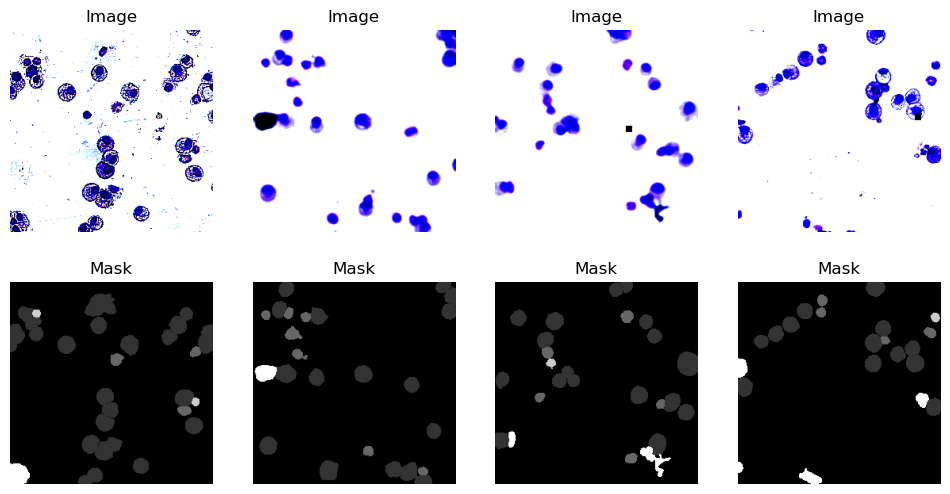

Validation Dataset:


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6897851..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7069099..2.3437037].


Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 256, 256])


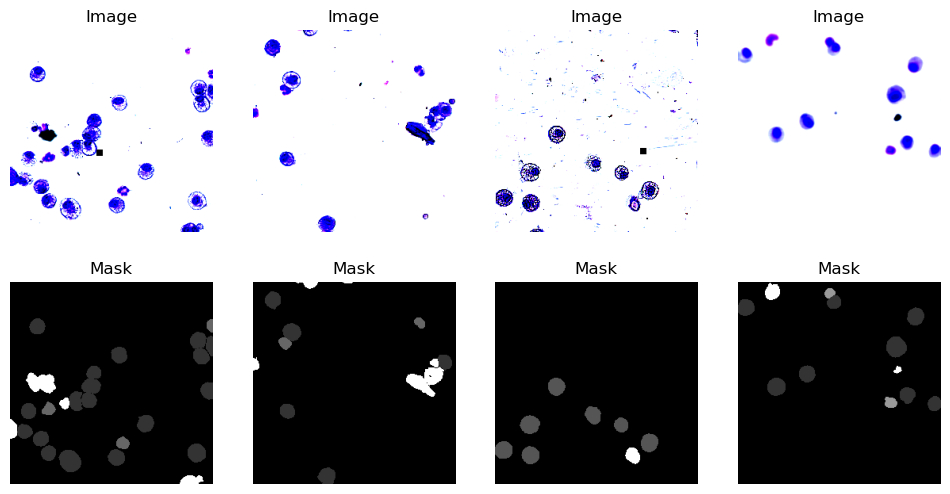

Test Dataset:


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.378562].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3611329].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3959913].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5105041..2.3262744].


Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 256, 256])


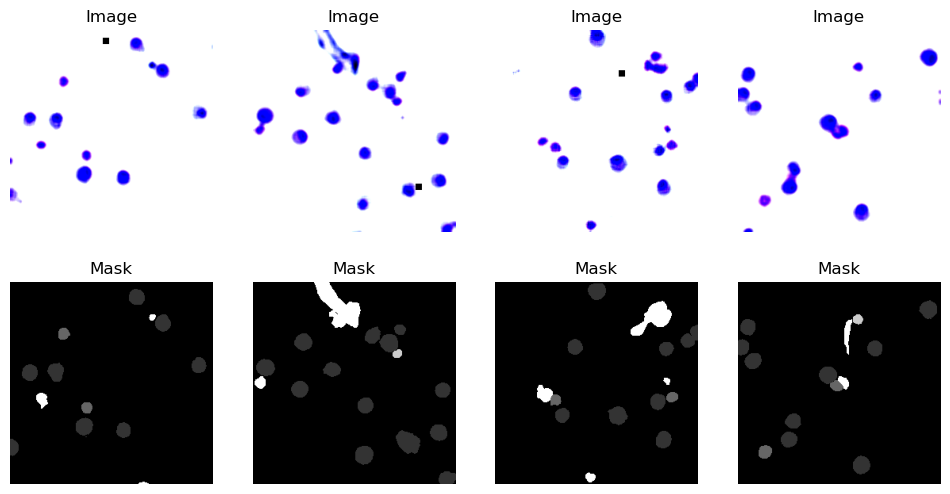

In [17]:
# Check data loaders
print("Training Dataset:")
image_train_batch, mask_train_batch = check_dataloader(train_loader)
print("Validation Dataset:")
image_val_batch, mask_val_batch = check_dataloader(val_loader)
print("Test Dataset:")
image_test_batch, mask_test_batch = check_dataloader(test_loader)

# Defining the Lighning Module

## UNet 

In [18]:
from torchmetrics.segmentation import MeanIoU
from torchmetrics.classification import MulticlassAccuracy as Accuracy

LEARNING_RATE = 1e-3
NUM_CLASSES = 7

class UNet(L.LightningModule):
    def __init__(self):
        super(UNet, self).__init__()
        self.model = smp.Unet(
            encoder_name="resnet34",        # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
            encoder_weights="imagenet",     # use `imagenet` pre-trained weights for encoder initialization
            in_channels=3,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
            classes=NUM_CLASSES,            # model output channels (number of classes in your dataset)
        )
        self.criterion = nn.CrossEntropyLoss()
        self.train_accuracy = Accuracy(num_classes=NUM_CLASSES, average='macro')  # Độ chính xác cho huấn luyện
        self.val_accuracy = Accuracy(num_classes=NUM_CLASSES, average='macro')    # Độ chính xác cho xác thực
        self.test_accuracy = Accuracy(num_classes=NUM_CLASSES, average='macro')   # Độ chính xác cho kiểm tra        
        self.metric = MeanIoU(num_classes=NUM_CLASSES)
        
    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, masks = batch
        images, masks = images.to(self.device), masks.to(self.device)
        outputs = self(images)
        train_loss = self.criterion(outputs, masks)
        
        preds = torch.argmax(outputs, dim=1).squeeze()

        # Tính toán độ chính xác
        train_acc = self.train_accuracy(preds, masks)
        train_iou = self.metric(preds, masks)  # Tính toán IoU
        
        self.log('train_loss', train_loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', train_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_iou', train_iou, on_step=False, on_epoch=True, prog_bar=False)
        
        return train_loss

    def validation_step(self, batch, batch_idx):
        images, masks = batch
        images, masks = images.to(self.device), masks.to(self.device)
        outputs = self(images)
        val_loss = self.criterion(outputs, masks)
        
        preds = torch.argmax(outputs, dim=1).squeeze()

        # Tính toán độ chính xác
        val_acc = self.val_accuracy(preds, masks)
        val_iou = self.metric(preds, masks)  # Tính toán IoU
        
        self.log('val_loss', val_loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_acc', val_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_iou', val_iou, on_step=False, on_epoch=True, prog_bar=False)
        
        return val_loss
    
    def test_step(self, batch, batch_idx):
        images, masks = batch
        images, masks = images.to(self.device), masks.to(self.device)
        outputs = self(images)
        test_loss = self.criterion(outputs, masks)  # CrossEntropyLoss yêu cầu đầu ra và mục tiêu có kích thước phù hợp

        # Chuyển đổi đầu ra sang nhị phân bằng cách lấy lớp có xác suất cao nhất
        preds = torch.argmax(outputs, dim=1)

        # Tính toán độ chính xác
        test_acc = self.test_accuracy(preds, masks)
        test_iou = self.metric(preds, masks)  # Tính toán IoU
        
        self.log('test_loss', test_loss, on_step=True, on_epoch=False)
        self.log('test_acc', test_acc, on_step=True, on_epoch=False)
        self.log('test_iou', test_iou, on_step=True, on_epoch=False)
        
        return test_loss
    
    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=LEARNING_RATE)
        return optimizer

## ResUNet

In [19]:
class ResUNet(L.LightningModule):
    def __init__(self):
        super(ResUNet, self).__init__()
        self.model = smp.ResUnet(
            encoder_name="resnet34",        # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
            encoder_weights="imagenet",     # use `imagenet` pre-trained weights for encoder initialization
            in_channels=3,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
            classes=NUM_CLASSES,            # model output channels (number of classes in your dataset)
        )
        self.criterion = nn.CrossEntropyLoss()
        self.train_accuracy = Accuracy(num_classes=NUM_CLASSES, average='macro')  # Độ chính xác cho huấn luyện
        self.val_accuracy = Accuracy(num_classes=NUM_CLASSES, average='macro')    # Độ chính xác cho xác thực
        self.test_accuracy = Accuracy(num_classes=NUM_CLASSES, average='macro')   # Độ chính xác cho kiểm tra        
        self.metric = MeanIoU(num_classes=NUM_CLASSES)
        
    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, masks = batch
        images, masks = images.to(self.device), masks.to(self.device)
        outputs = self(images)
        train_loss = self.criterion(outputs, masks)
        
        preds = torch.argmax(outputs, dim=1).squeeze()

        # Tính toán độ chính xác
        train_acc = self.train_accuracy(preds, masks)
        train_iou = self.metric(preds, masks)  # Tính toán IoU
        
        self.log('train_loss', train_loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', train_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_iou', train_iou, on_step=False, on_epoch=True, prog_bar=False)
        
        return train_loss

    def validation_step(self, batch, batch_idx):
        images, masks = batch
        images, masks = images.to(self.device), masks.to(self.device)
        outputs = self(images)
        val_loss = self.criterion(outputs, masks)
        
        preds = torch.argmax(outputs, dim=1).squeeze()

        # Tính toán độ chính xác
        val_acc = self.val_accuracy(preds, masks)
        val_iou = self.metric(preds, masks)  # Tính toán IoU
        
        self.log('val_loss', val_loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_acc', val_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_iou', val_iou, on_step=False, on_epoch=True, prog_bar=False)
        
        return val_loss
    
    def test_step(self, batch, batch_idx):
        images, masks = batch
        images, masks = images.to(self.device), masks.to(self.device)
        outputs = self(images)
        test_loss = self.criterion(outputs, masks)  # CrossEntropyLoss yêu cầu đầu ra và mục tiêu có kích thước phù hợp

        # Chuyển đổi đầu ra sang nhị phân bằng cách lấy lớp có xác suất cao nhất
        preds = torch.argmax(outputs, dim=1)

        # Tính toán độ chính xác
        test_acc = self.test_accuracy(preds, masks)
        test_iou = self.metric(preds, masks)  # Tính toán IoU
        
        self.log('test_loss', test_loss, on_step=True, on_epoch=False)
        self.log('test_acc', test_acc, on_step=True, on_epoch=False)
        self.log('test_iou', test_iou, on_step=True, on_epoch=False)
        
        return test_loss
    
    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=LEARNING_RATE)
        return optimizer

## DeepLabV3

In [20]:
class DeepLabV3(L.LightningModule):
    def __init__(self):
        super(DeepLabV3, self).__init__()
        self.model = smp.DeepLabV3(
            encoder_name="resnet34",        # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
            encoder_weights="imagenet",     # use `imagenet` pre-trained weights for encoder initialization
            in_channels=3,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
            classes=NUM_CLASSES,            # model output channels (number of classes in your dataset)
        )
        self.criterion = nn.CrossEntropyLoss()
        self.train_accuracy = Accuracy(num_classes=NUM_CLASSES, average='macro')  # Độ chính xác cho huấn luyện
        self.val_accuracy = Accuracy(num_classes=NUM_CLASSES, average='macro')    # Độ chính xác cho xác thực
        self.test_accuracy = Accuracy(num_classes=NUM_CLASSES, average='macro')   # Độ chính xác cho kiểm tra        
        self.metric = MeanIoU(num_classes=NUM_CLASSES)
        
    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, masks = batch
        images, masks = images.to(self.device), masks.to(self.device)
        outputs = self(images)
        train_loss = self.criterion(outputs, masks)
        
        preds = torch.argmax(outputs, dim=1).squeeze()

        # Tính toán độ chính xác
        train_acc = self.train_accuracy(preds, masks)
        train_iou = self.metric(preds, masks)  # Tính toán IoU
        
        self.log('train_loss', train_loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', train_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_iou', train_iou, on_step=False, on_epoch=True, prog_bar=False)
        
        return train_loss

    def validation_step(self, batch, batch_idx):
        images, masks = batch
        images, masks = images.to(self.device), masks.to(self.device)
        outputs = self(images)
        val_loss = self.criterion(outputs, masks)
        
        preds = torch.argmax(outputs, dim=1).squeeze()

        # Tính toán độ chính xác
        val_acc = self.val_accuracy(preds, masks)
        val_iou = self.metric(preds, masks)  # Tính toán IoU
        
        self.log('val_loss', val_loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_acc', val_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_iou', val_iou, on_step=False, on_epoch=True, prog_bar=False)
        
        return val_loss
    
    def test_step(self, batch, batch_idx):
        images, masks = batch
        images, masks = images.to(self.device), masks.to(self.device)
        outputs = self(images)
        test_loss = self.criterion(outputs, masks)  # CrossEntropyLoss yêu cầu đầu ra và mục tiêu có kích thước phù hợp

        # Chuyển đổi đầu ra sang nhị phân bằng cách lấy lớp có xác suất cao nhất
        preds = torch.argmax(outputs, dim=1)

        # Tính toán độ chính xác
        test_acc = self.test_accuracy(preds, masks)
        test_iou = self.metric(preds, masks)  # Tính toán IoU
        
        self.log('test_loss', test_loss, on_step=True, on_epoch=False)
        self.log('test_acc', test_acc, on_step=True, on_epoch=False)
        self.log('test_iou', test_iou, on_step=True, on_epoch=False)
        
        return test_loss
    
    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=LEARNING_RATE)
        return optimizer

# Training models

In [32]:
#===== Start training the model =====
EPOCHS = 1000

# Initialize the models
models = [UNet(), ResUNet(), DeepLabV3()]

log_dir = os.path.join(os.getcwd(), "logs")
# Check if the logs directory exists, if not, create it
if not os.path.exists(log_dir):
    os.makedirs(log_dir)
print(f"Logging directory: {log_dir}")

# Train and test each model sequentially
for model in models:
    # Set a unique experiment name and run name for each model
    experiment_name = model.__class__.__name__
    run_name = model.__class__.__name__
    
    # Initialize the MLFlowLogger with unique experiment name and run name
    mlflow_logger = MLFlowLogger(experiment_name=experiment_name, tracking_uri=f"file:{log_dir}", run_name=run_name, log_model=True)
    
    # Log hyperparameters
    mlflow_logger.log_hyperparams({
        "device": device,
        "torch_version": torch.__version__,
        "optimizer": "Adam",
        "loss": "CrossEntropyLoss",
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "learning_rate": LEARNING_RATE,
        "epochs": EPOCHS,
        "seed": 42,
        "num_classes": NUM_CLASSES,
        "segmentation_model": experiment_name
    })
    
    # Initialize the Trainer with the MLFlowLogger
    trainer = L.Trainer(max_epochs=EPOCHS, logger=mlflow_logger, devices=1, accelerator=device)
    
    # Train the model
    trainer.fit(model, train_loader, val_loader)
    
    # Test the model
    trainer.test(model, test_loader)
    
    # Clear GPU memory
    del model
    torch.cuda.empty_cache()

Experiment with name UNet not found. Creating it.


Logging directory: /mnt/d/03_OneDrive/OneDrive/01_WORKING/02_cell_detection/Code/Cell-Detection/logs


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type               | Params | Mode 
--------------------------------------------------------------
0 | model          | Unet               | 24.4 M | train
1 | criterion      | CrossEntropyLoss   | 0      | train
2 | train_accuracy | MulticlassAccuracy | 0      | train
3 | val_accuracy   | MulticlassAccuracy | 0      | train
4 | test_accuracy  | MulticlassAccuracy | 0      | train
5 | metric         | MeanIoU            | 0      | train
--------------------------------------------------------------
24.4 M    Trainable params
0         Non-trainable params
24.4 M    Total params
97.749    Total estimated model params size (MB)
193       Modules in train mode
0         Modules in eval mode


Epoch 999: 100%|██████████| 8/8 [00:17<00:00,  0.46it/s, v_num=9efb, val_loss=0.139, val_acc=0.583, train_loss=0.00183, train_acc=0.995] 

`Trainer.fit` stopped: `max_epochs=1000` reached.


...

Epoch 999: 100%|██████████| 8/8 [00:17<00:00,  0.45it/s, v_num=167b, val_loss=0.129, val_acc=0.518, train_loss=0.0135, train_acc=0.968] 

`Trainer.fit` stopped: `max_epochs=1000` reached.


Epoch 999: 100%|██████████| 8/8 [00:21<00:00,  0.37it/s, v_num=167b, val_loss=0.129, val_acc=0.518, train_loss=0.0135, train_acc=0.968]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 2/2 [00:02<00:00,  0.96it/s]


# Check results

In [33]:
log_dir = os.path.join(os.getcwd(), "logs/")
print(log_dir)
!mlflow ui --backend-store-uri {log_dir} --port 5000

/mnt/d/03_OneDrive/OneDrive/01_WORKING/02_cell_detection/Code/Cell-Detection/logs/
/home/thanglx/miniconda3/envs/pytorch/lib/python3.10/site-packages/pydantic/_internal/_config.py:345: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
  warnings.warn(message, UserWarning)
[2024-12-29 19:01:58 +0000] [239982] [INFO] Starting gunicorn 21.2.0
[2024-12-29 19:01:58 +0000] [239982] [INFO] Listening at: http://127.0.0.1:5000 (239982)
[2024-12-29 19:01:58 +0000] [239982] [INFO] Using worker: sync
[2024-12-29 19:01:58 +0000] [239986] [INFO] Booting worker with pid: 239986
[2024-12-29 19:01:58 +0000] [239987] [INFO] Booting worker with pid: 239987
[2024-12-29 19:01:58 +0000] [239988] [INFO] Booting worker with pid: 239988
[2024-12-29 19:01:59 +0000] [239989] [INFO] Booting worker with pid: 239989
^C
[2024-12-29 19:16:58 +0000] [239982] [INFO] Handling signal: int
[2024-12-29 19:16:58 +0000] [239988] [INFO] Worker exiting (pid: 239988)
[20